# Kvantová pravděpodobnost -- praktické ukázky pro KMA/PSA

Tento notebook doprovází doplněné sekce v *Přehledu definic a vět KMA/PSA*:

1. **Bornovo pravidlo** (část 1, kap. 4.1 -- Alternativní rozdělení)
2. **Bellova nerovnost / CHSH** (část 1, kap. 2.4)
3. **Kvantová tomografie stavu** (část 2, kap. 9.2 -- Bodové odhady)
4. **Von Neumannova entropie** (část 2, kap. 8.2.2 -- Míry variability)

Vše je postaveno pouze na `numpy` a `matplotlib` -- žádné speciální kvantové knihovny nejsou potřeba,
protože pro jeden a dva qubity si vystačíme s ručním maticovým počtem (stavové vektory jsou jen
komplexní vektory v $\mathbb{C}^2$, resp. $\mathbb{C}^4$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

## 1. Qubit a Bornovo pravidlo

Qubit je jednotkový vektor $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle \in \mathbb{C}^2$,
$|\alpha|^2+|\beta|^2=1$. Změříme-li ho v bázi $\{|0\rangle,|1\rangle\}$, dostaneme podle
**Bornova pravidla** náhodnou veličinu $X \sim A(p)$ s $p=|\alpha|^2$ (přesně jako v doplněné
poznámce u alternativního rozdělení).

Níže: zvolíme konkrétní qubit, spočteme teoretické $p$, pak ho "změříme" $n$-krát a sledujeme,
jak se výběrový průměr $\overline{X}_n$ blíží teoretické hodnotě -- je to tentýž zákon velkých čísel,
který znáte z klasické mince, jen aplikovaný na kvantová data.

In [2]:
def make_qubit(theta, phi=0.0):
    # Qubit na Blochove sfere: |psi> = cos(theta/2)|0> + e^{i phi} sin(theta/2)|1>
    alpha = np.cos(theta / 2)
    beta = np.exp(1j * phi) * np.sin(theta / 2)
    return np.array([alpha, beta])

# Priklad: theta = 60 stupnu => p = |alpha|^2 = cos^2(30 deg)
theta = np.deg2rad(60)
psi = make_qubit(theta)
p_true = np.abs(psi[0])**2
print(f"stav |psi> = {psi}")
print(f"teoreticke p = |alpha|^2 = {p_true:.4f}")

stav |psi> = [0.8660254+0.j 0.5      +0.j]
teoreticke p = |alpha|^2 = 0.7500


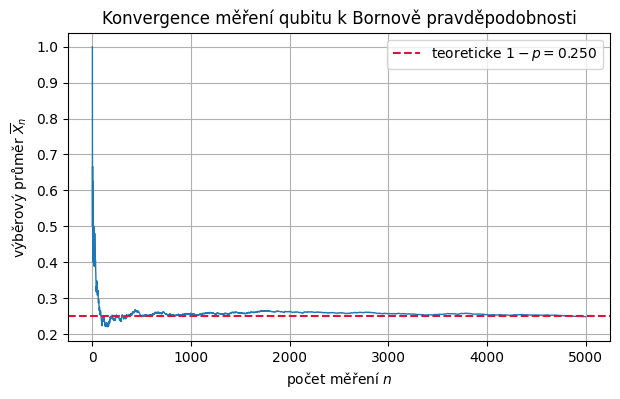

In [3]:
def measure_qubit(psi, n, rng):
    p = np.abs(psi[0])**2
    # vysledek 0 s pravdepodobnosti p, vysledek 1 s pravdepodobnosti 1-p
    return rng.choice([0, 1], size=n, p=[p, 1 - p])

n_max = 5000
outcomes = measure_qubit(psi, n_max, rng)
running_mean = np.cumsum(outcomes) / np.arange(1, n_max + 1)

# pozor: X ~ A(p) s P(X=1) = 1-p_true, takze prumer konverguje k (1-p_true)
target = 1 - p_true

plt.plot(running_mean, lw=1)
plt.axhline(target, color="crimson", ls="--", label=f"teoreticke $1-p={target:.3f}$")
plt.xlabel("počet měření $n$")
plt.ylabel(r"výběrový průměr $\overline{X}_n$")
plt.title("Konvergence měření qubitu k Bornově pravděpodobnosti")
plt.legend()
plt.show()

**Pro přednášku:** stejný graf byste nakreslila pro klasickou minci -- studenti tak hned vidí,
že "kvantovost" je jen v tom, *odkud* se vzalo $p$ (z komplexních amplitud), ne v tom, jak se s ním
počítá.

## 2. Bellova nerovnost (CHSH) -- klasický model vs. kvantová simulace

Připomeňme kombinaci korelací
$$S = E(a,b) - E(a,b') + E(a',b) + E(a',b'),$$
kde $E(x,y)=\mathbb E[A(x,\lambda)\,B(y,\lambda)]$ a $A,B \in \{-1,+1\}$.

- **Klasický lokální model:** existuje skrytá proměnná $\lambda$ (sdílená mezi Alicí a Bobem) a
  deterministické strategie $A(\theta,\lambda), B(\theta,\lambda)$. Ukážeme konkrétní model a
  spočteme $S$ -- musí vyjít $|S|\le 2$.
- **Kvantový model:** dvojice qubitů v singletním (zapleteném) stavu. Pravděpodobnosti výsledků
  spočteme přímo z Bornova pravidla pro dvouqubitový stav, "naměříme" je Monte Carlo simulací a
  spočteme $S$ -- vyjde $2\sqrt{2}$, tedy nad klasickou mezí.

In [4]:
# --- 2a. Klasicky lokalni (hidden-variable) model -----------------------
# Sdilena skryta promenna: uhel lambda, rovnomerne na [0, 2*pi)
# Strategie: A(theta, lambda) = sign(cos(theta - lambda))
#            B(theta, lambda) = -sign(cos(theta - lambda))   (antikorelace pri stejnem uhlu)
# Toto je bezny "lokalne realisticky" model z ucebnic -- zadna komunikace mezi
# Alici a Bobem, jen spolecne sdilene lambda.

def classical_outcome(theta, lam, sign=1):
    return sign * np.sign(np.cos(theta - lam))

def chsh_classical(a, a2, b, b2, n, rng):
    lam = rng.uniform(0, 2 * np.pi, size=n)
    A_a  = classical_outcome(a,  lam, +1)
    A_a2 = classical_outcome(a2, lam, +1)
    B_b  = classical_outcome(b,  lam, -1)
    B_b2 = classical_outcome(b2, lam, -1)
    E_ab   = np.mean(A_a  * B_b)
    E_ab2  = np.mean(A_a  * B_b2)
    E_a2b  = np.mean(A_a2 * B_b)
    E_a2b2 = np.mean(A_a2 * B_b2)
    S = E_ab - E_ab2 + E_a2b + E_a2b2
    return S, (E_ab, E_ab2, E_a2b, E_a2b2)

a, a2 = 0.0, np.pi / 2
b, b2 = np.pi / 4, 3 * np.pi / 4

S_classical, corrs_classical = chsh_classical(a, a2, b, b2, n=200_000, rng=rng)
print(f"Klasicky model:  S = {S_classical:.3f}   (v absolutni hodnote |S| = {abs(S_classical):.3f}, mez je |S| <= 2)")

Klasicky model:  S = -2.000   (v absolutni hodnote |S| = 2.000, mez je |S| <= 2)


In [5]:
# --- 2b. Kvantovy model: singletni stav dvou qubitu ---------------------
# |psi> = (|01> - |10>) / sqrt(2), baze {|00>,|01>,|10>,|11>}
psi_singlet = np.array([0, 1, -1, 0]) / np.sqrt(2)

def qubit_basis(theta):
    # Projekcni vektory +1/-1 pro mereni spinu pod uhlem theta (v rovine)
    plus  = np.array([np.cos(theta / 2), np.sin(theta / 2)])
    minus = np.array([-np.sin(theta / 2), np.cos(theta / 2)])
    return plus, minus

def joint_probs(theta_a, theta_b, psi):
    # Pravdepodobnosti (++, +-, -+, --) pro mereni Alice pod theta_a, Boba pod theta_b
    a_plus, a_minus = qubit_basis(theta_a)
    b_plus, b_minus = qubit_basis(theta_b)
    probs = {}
    for sa, va in [("+", a_plus), ("-", a_minus)]:
        for sb, vb in [("+", b_plus), ("-", b_minus)]:
            basis_vec = np.kron(va, vb)
            amp = np.vdot(basis_vec, psi)
            probs[(sa, sb)] = np.abs(amp) ** 2
    return probs

def sample_correlation(theta_a, theta_b, psi, n, rng):
    probs = joint_probs(theta_a, theta_b, psi)
    outcomes = list(probs.keys())
    p = np.array([probs[o] for o in outcomes])
    p = p / p.sum()  # numericka jistota
    idx = rng.choice(len(outcomes), size=n, p=p)
    sign = {"+": 1, "-": -1}
    vals = np.array([sign[outcomes[i][0]] * sign[outcomes[i][1]] for i in idx])
    return vals.mean()

n_shots = 200_000
E_ab   = sample_correlation(a,  b,  psi_singlet, n_shots, rng)
E_ab2  = sample_correlation(a,  b2, psi_singlet, n_shots, rng)
E_a2b  = sample_correlation(a2, b,  psi_singlet, n_shots, rng)
E_a2b2 = sample_correlation(a2, b2, psi_singlet, n_shots, rng)

S_quantum = E_ab - E_ab2 + E_a2b + E_a2b2
print(f"Kvantova simulace (Monte Carlo, {n_shots} mereni na kombinaci):")
print(f"  E(a,b)={E_ab:+.3f}  E(a,b')={E_ab2:+.3f}  E(a',b)={E_a2b:+.3f}  E(a',b')={E_a2b2:+.3f}")
print(f"  S = {S_quantum:.3f}   (v absolutni hodnote |S| = {abs(S_quantum):.3f}; teoreticka kvantova mez 2*sqrt(2) = {2*np.sqrt(2):.3f}, klasicka mez = 2)")

Kvantova simulace (Monte Carlo, 200000 mereni na kombinaci):
  E(a,b)=-0.710  E(a,b')=+0.705  E(a',b)=-0.709  E(a',b')=-0.707
  S = -2.830   (v absolutni hodnote |S| = 2.830; teoreticka kvantova mez 2*sqrt(2) = 2.828, klasicka mez = 2)


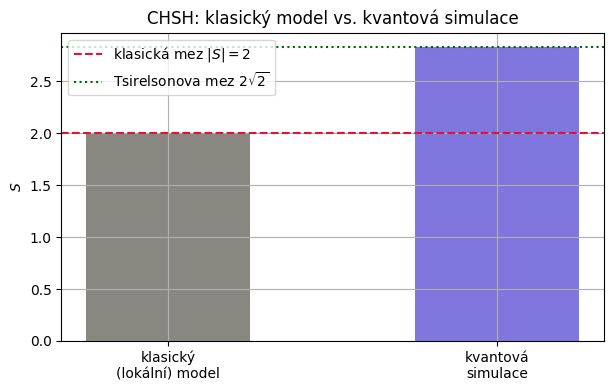

In [6]:
fig, ax = plt.subplots()
labels = ["klasický\n(lokální) model", "kvantová\nsimulace"]
values = [abs(S_classical), abs(S_quantum)]  # Vetu 2.4 zajima |S|, znamenko zavisi jen na konvenci uhlu
colors = ["#888780", "#7F77DD"]
ax.bar(labels, values, color=colors, width=0.5)
ax.axhline(2, color="crimson", ls="--", label="klasická mez $|S|=2$")
ax.axhline(2 * np.sqrt(2), color="darkgreen", ls=":", label=r"Tsirelsonova mez $2\sqrt{2}$")
ax.set_ylabel("$S$")
ax.set_title("CHSH: klasický model vs. kvantová simulace")
ax.legend()
plt.show()

*(Znaménko $S$ závisí jen na libovolné konvenci, jak jsme si zvolili osy měření -- Věta o CHSH nerovnosti mluví o $|S|$, proto tabulka i graf výše používají absolutní hodnotu.)*

**Pro přednášku:** oba modely používají *stejnou* Monte Carlo architekturu (skryté/kvantové
"nastavení" $\to$ výsledek $\pm1$ $\to$ průměrování). Liší se jen v tom, odkud se berou
pravděpodobnosti výsledků -- to je přesně ten bod, který chcete studentům ukázat: klasická
pravděpodobnost (Definice 1.8) tuto kvantovou korelaci nedokáže reprodukovat žádnou volbou
$\lambda$.

## 3. Kvantová tomografie stavu (bodový odhad)

Neznáme-li $p=|\alpha|^2$, odhadneme ho z $n$ opakovaných měření stejným způsobem jako u mince:
$\widehat p = \overline X_n$, s intervalem spolehlivosti podle vzorce pro alternativní rozdělení
(část 2, kap. 9.3):
$$\widehat p \pm u_{1-\alpha/2}\sqrt{\frac{\widehat p (1-\widehat p)}{n}}.$$

Ukážeme, jak se odhad i šířka intervalu zlepšují s rostoucím $n$.

In [7]:
from scipy import stats  # jen kvuli kvantilu normalniho rozdeleni

p_true_tomo = 0.7  # "skryty" parametr kvantoveho stavu, ktery se snazime odhadnout
ns = np.array([10, 30, 100, 300, 1000, 3000, 10000])
alpha = 0.05
u = stats.norm.ppf(1 - alpha / 2)

estimates, halfwidths = [], []
for n in ns:
    x = rng.choice([1, 0], size=n, p=[p_true_tomo, 1 - p_true_tomo])
    phat = x.mean()
    hw = u * np.sqrt(phat * (1 - phat) / n)
    estimates.append(phat)
    halfwidths.append(hw)

for n, phat, hw in zip(ns, estimates, halfwidths):
    print(f"n={n:6d}   p_hat={phat:.3f}   95% CI = [{phat-hw:.3f}, {phat+hw:.3f}]")

n=    10   p_hat=0.900   95% CI = [0.714, 1.086]
n=    30   p_hat=0.667   95% CI = [0.498, 0.835]
n=   100   p_hat=0.680   95% CI = [0.589, 0.771]
n=   300   p_hat=0.733   95% CI = [0.683, 0.783]
n=  1000   p_hat=0.667   95% CI = [0.638, 0.696]
n=  3000   p_hat=0.712   95% CI = [0.696, 0.729]
n= 10000   p_hat=0.710   95% CI = [0.701, 0.719]


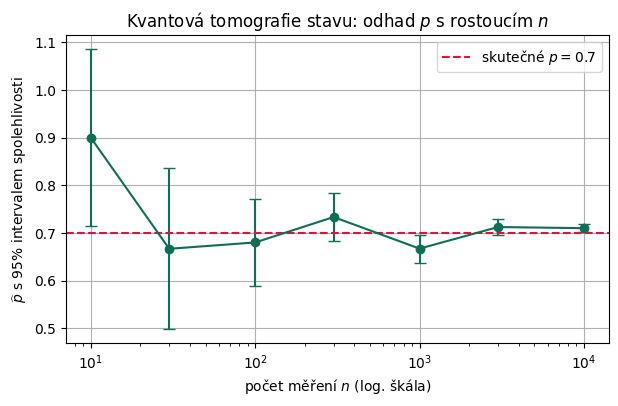

In [8]:
plt.errorbar(ns, estimates, yerr=halfwidths, fmt="o-", capsize=4, color="#0F6E56")
plt.axhline(p_true_tomo, color="crimson", ls="--", label=f"skutečné $p={p_true_tomo}$")
plt.xscale("log")
plt.xlabel("počet měření $n$ (log. škála)")
plt.ylabel(r"$\widehat p$ s 95% intervalem spolehlivosti")
plt.title("Kvantová tomografie stavu: odhad $p$ s rostoucím $n$")
plt.legend()
plt.show()

**Pro přednášku:** graf je formálně identický s tím, co byste nakreslila pro odhad
pravděpodobnosti úspěchu mincí -- to je přesně poselství sekce 9.2: kvantová tomografie *je*
bodový odhad parametru $p$ alternativního rozdělení, jen ta "mince" je qubit.

## 4. Von Neumannova entropie

Matice hustoty pro obecný smíšený stav qubitu s "Blochovým vektorem" délky $r\in[0,1]$ má
vlastní čísla $\lambda_{1,2} = \frac{1\pm r}{2}$. Von Neumannova entropie
$$S(\rho) = -\sum_i \lambda_i \log_2 \lambda_i$$
je tedy funkcí jediného parametru $r$: $r=1$ odpovídá čistému stavu ($S=0$), $r=0$ maximálně
smíšenému stavu ($S=1$ bit -- shoduje se se Shannonovou entropií rovnoměrného rozdělení na
dvou hodnotách).

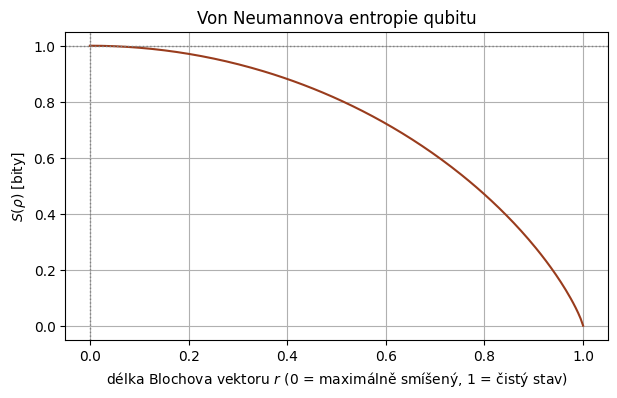

In [9]:
def von_neumann_entropy(r):
    lam1 = (1 + r) / 2
    lam2 = (1 - r) / 2
    terms = []
    for lam in (lam1, lam2):
        terms.append(0.0 if lam <= 0 else -lam * np.log2(lam))
    return sum(terms)

r_vals = np.linspace(0, 1, 200)
S_vals = [von_neumann_entropy(r) for r in r_vals]

plt.plot(r_vals, S_vals, color="#993C1D")
plt.xlabel(r"délka Blochova vektoru $r$ (0 = maximálně smíšený, 1 = čistý stav)")
plt.ylabel(r"$S(\rho)$ [bity]")
plt.title("Von Neumannova entropie qubitu")
plt.axhline(1, color="gray", ls=":", lw=1)
plt.axvline(0, color="gray", ls=":", lw=1)
plt.show()

**Pro přednášku:** bod $r=0$ (diagonální matice hustoty s $\lambda_1=\lambda_2=0{,}5$)
je přesně situace z doplněné poznámky v kap. 8.2.2 -- diagonální $\rho$ se stejnými prvky jako
klasické rovnoměrné rozdělení dává $S(\rho)=H$. Křivka ukazuje, co se stane, když se stav
"kvantověji" odchýlí od klasické diagonální podoby.

## Shrnutí pro přednášku

| Sekce v přehledu | Co ukazuje notebook |
|---|---|
| 4.1 Alternativní rozdělení -- Bornovo pravidlo | konvergence měření qubitu k teoretickému $p$ |
| 2.4 Bellova nerovnost | číselné porušení $S\le 2$ kvantovou simulací ($2\sqrt{2}$) |
| 9.2 Bodové odhady -- kvantová tomografie | odhad $p$ a interval spolehlivosti s rostoucím $n$ |
| 8.2.2 Von Neumannova entropie | entropie jako funkce míry smíšenosti stavu |

Všechny čtyři ukázky používají jen `numpy`/`matplotlib`/`scipy.stats` -- dají se spustit přímo
na hodině nebo zadat studentům jako cvičení (např. změnit úhly v CHSH a sledovat, jak $S$ klesá
pod $2\sqrt{2}$, nebo změnit $p_{\text{true}}$ v tomografii).